**Code Summary**

The Jupyter cell loads the raw *Eurasian Otter* dataset via `DataImporter`, then calls `create_train_test_split_otter` to deterministically build three splits:

1. **Inference** – all footprints from the “Fieldprints Portugal” source.
2. **Test** – every DNA-confirmed footprint from Lower Saxony plus fixed, seed‑controlled samples of individuals from “Own Data Collection” (3♀, 3♂) and “Vetrecova et al.” (2♀, 2♂).
3. **Train** – all remaining individuals.

The train data are assigned fold IDs using `_make_folds` (group‑stratified K‑fold with `NUM_FOLDS = 3`), ensuring footprints from the same individual stay in a single fold. Each split is stored as a Parquet file under `data/splits/eurasian_otter/`.

Finally, `run_summary` computes dataset statistics and saves them (including plots) to `results/data/eurasian_otter_summary.csv` and the corresponding figure directory.


In [1]:
from pathlib import Path

from FIT_python.data_split_and_summary.data_import_wrapper import DataImporter
from FIT_python.data_split_and_summary.split_utils import (
    create_train_test_split_otter,
    _make_folds,
)
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from FIT_python.config import (
    RAW_DIR,
    SPLITS_DIR,
    RESULTS_DATA_DIR,
    DEFAULT_TARGETS,
    GROUP_COL,
    NUM_FOLDS,
)

# --- 1. Load the raw Eurasian otter table
importer = DataImporter(RAW_DIR, target_cols=DEFAULT_TARGETS)
dfs = importer.run()
otter_key = next(k for k in dfs if "otter" in k.lower())
df = dfs[otter_key]

# --- 2. Create deterministic train/test/inference splits
train_df, test_df, inf_df = create_train_test_split_otter(df)

# --- 3. Assign folds for cross‑validation
y_train = train_df["sex"].map({"f": 0, "m": 1})
folds, _ = _make_folds(train_df, y_train, n_splits=NUM_FOLDS, group_col=GROUP_COL)
train_df = train_df.assign(Fold=folds)

# --- 4. Save split files
split_dir = SPLITS_DIR / "eurasian_otter"
split_dir.mkdir(parents=True, exist_ok=True)
train_df.to_parquet(split_dir / "train.parquet", index=False)
test_df.to_parquet(split_dir / "test.parquet", index=False)
inf_df.to_parquet(split_dir / "inference.parquet", index=False)




🔄 Starte Otter-Splitting...
🛰️ Inference-Split – 81 Zeilen
↪️ Inference 'dataorigin': ['Fieldprints Portugal']
↪️ Inference 'sex' unique: ['unknown']

🧹 df_clean – 547 Zeilen (ohne Portugal)
🧾 dataorigin: ['Vetrecova et al' 'Own Data Collection' 'Fieldprints Lower Saxony']
🧬 sex: ['f' 'm']
🆔 individual_id: 41

🔬 Erzeuge Test-Split...
✅ Test-Split fertig – 152 Zeilen
👤 Test-Individuals: 14
📊 Test 'dataorigin': dataorigin
Own Data Collection         76
Vetrecova et al             40
Fieldprints Lower Saxony    36
🧬 Test 'sex': sex
f    86
m    66

🧠 Train-Split – 395 Zeilen
👤 Train-Individual IDs: 27
📊 Train 'dataorigin': dataorigin
Own Data Collection    343
Vetrecova et al         52
🧬 Train 'sex': sex
f    220
m    175

🎲 Berechne Fold-Zuordnung...

✅ Fold method used: stratified_group
📊 Fold-Verteilung:
Fold
0    123
1    142
2    130
Name: count, dtype: int64


C:\otter_fit\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\otter_fit\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids


**Otter Data Splitting Summary**

- **Inference split:** 81 rows from *Fieldprints Portugal*, all labeled with unknown sex.
- **Filtered data (`df_clean`):** 547 rows remaining after removing Portugal samples, spanning origins *Vetrecova et al.*, *Own Data Collection*, and *Fieldprints Lower Saxony*. Contains 41 unique individuals (sexes “f” and “m”).
- **Test split:** Created with 152 rows across 14 individuals. Distribution by origin:  
  - Own Data Collection – 76  
  - Vetrecova et al. – 40  
  - Fieldprints Lower Saxony – 36  
  Sex balance: 86 “f” vs. 66 “m”.
- **Train split:** Remaining 395 rows from 27 individuals.  
- A summary step was attempted but skipped because `eurasian_otter_summary.csv` already exists.


# Overview of the Notebook

This notebook performs a step-by-step analysis of Eurasian otter footprint data, from loading and styling through to feature exploration and visualization:

1. **Styling and Configuration**  
   - Import project paths and configuration constants.  
   - Apply a consistent “whitegrid” theme, custom DPI, font sizes, and a sex-specific color palette (`Female`, `Male`, `Unknown`) via `apply_style()`.

2. **Data Loading & Preprocessing**  
   - Read the training split from disk (`train.parquet`).  
   - Standardize the raw `sex` column (`'f'`, `'F'`, `0`, `'m'`, `'M'`, `1`) into `"Female"`, `"Male"`, or `"Unknown"` using `map_sex()`.

3. **Feature Correlation Heatmap**  
   - Compute a 2×2 panel of correlation heatmaps:  
     - **a)** Combined “distance / angle / triangles” feature groups.  
     - **b)** Distance features only.  
     - **c)** Angle features only.  
     - **d)** Triangle-based features only.  
   - Save the figure and display it inline.

4. **Sex-Discriminative Feature Selection**  
   - Exclude metadata columns and select the top four features that best distinguish sex (`univariate` selection).  
   - Filter out `"Unknown"` samples.  
   - Plot 2×2 boxplots of these four features, colored by `"Female"` vs. `"Male"`.

5. **UMAP Projection**  
   - Reduce all features to 2D via UMAP.  
   - Scatter-plot the embedding, colored by sex (`Female`, `Male`), to inspect class separation visually.

Each section is fully reproducible and leverages the project’s standardized plotting utilities to ensure consistency across analyses.
::contentReference[oaicite:0]{index=0}



[DEBUG] compute_summary called for eurasian_otter/inference, df shape = (81, 214)
[DEBUG] ds_label = eurasian_otter Inference
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['lutra_lutra']
[DEBUG] species_code = lutra lutra
[DEBUG] sex value counts:
sex
Unknown    81
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Male, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Unknown, subset shape = (81, 214)
[DEBUG]  n_fp=81, n_ind=1, n_tr=8
[DEBUG]   fp_per_ind summary: mean=81.0, sd=0.0
[DEBUG]   tr_per_ind summary: mean=8.0, sd=0.0
[DEBUG] Returning summary DataFrame with shape (3, 10)

[DEBUG] compute_summary called for eurasian_otter/test, df shape = (152, 214)
[DEBUG] ds_label = eurasian_otter Test
[DEBUG] specie

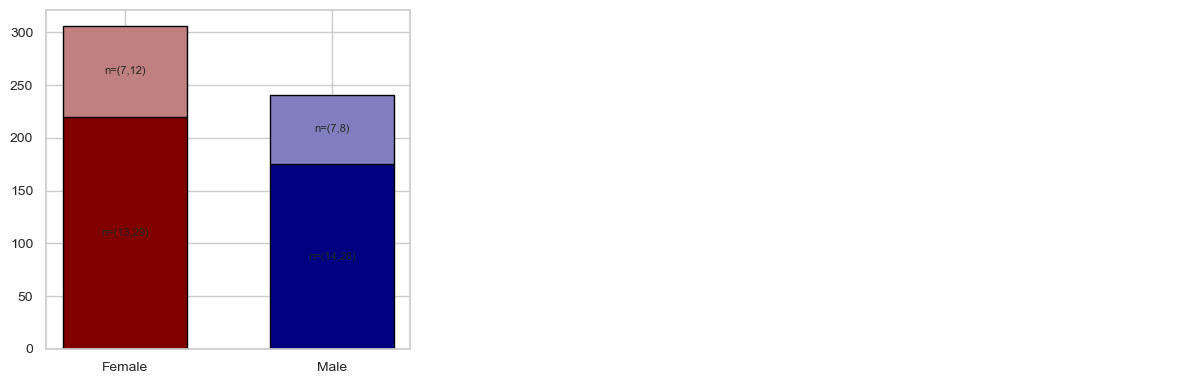

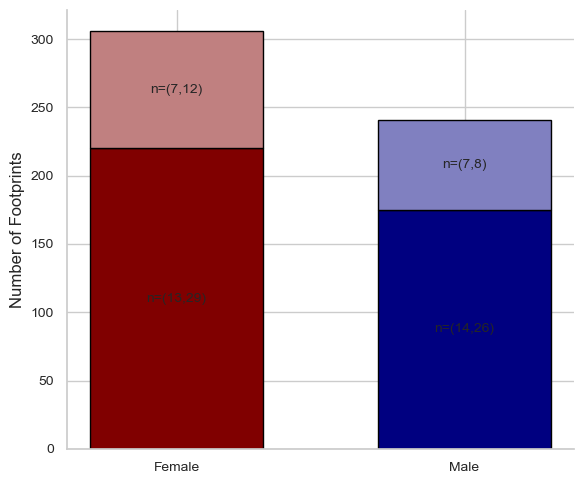

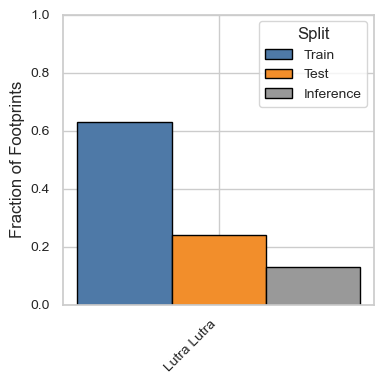

In [2]:
# --- 5. Generate summary statistics and plots
run_summary(
    split_dir,
    RESULTS_DATA_DIR / "eurasian_otter_summary.csv",
    RESULTS_DATA_DIR / "eurasian_otter_fig",
)


**a) Correlation Heatmap Panel**

[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.


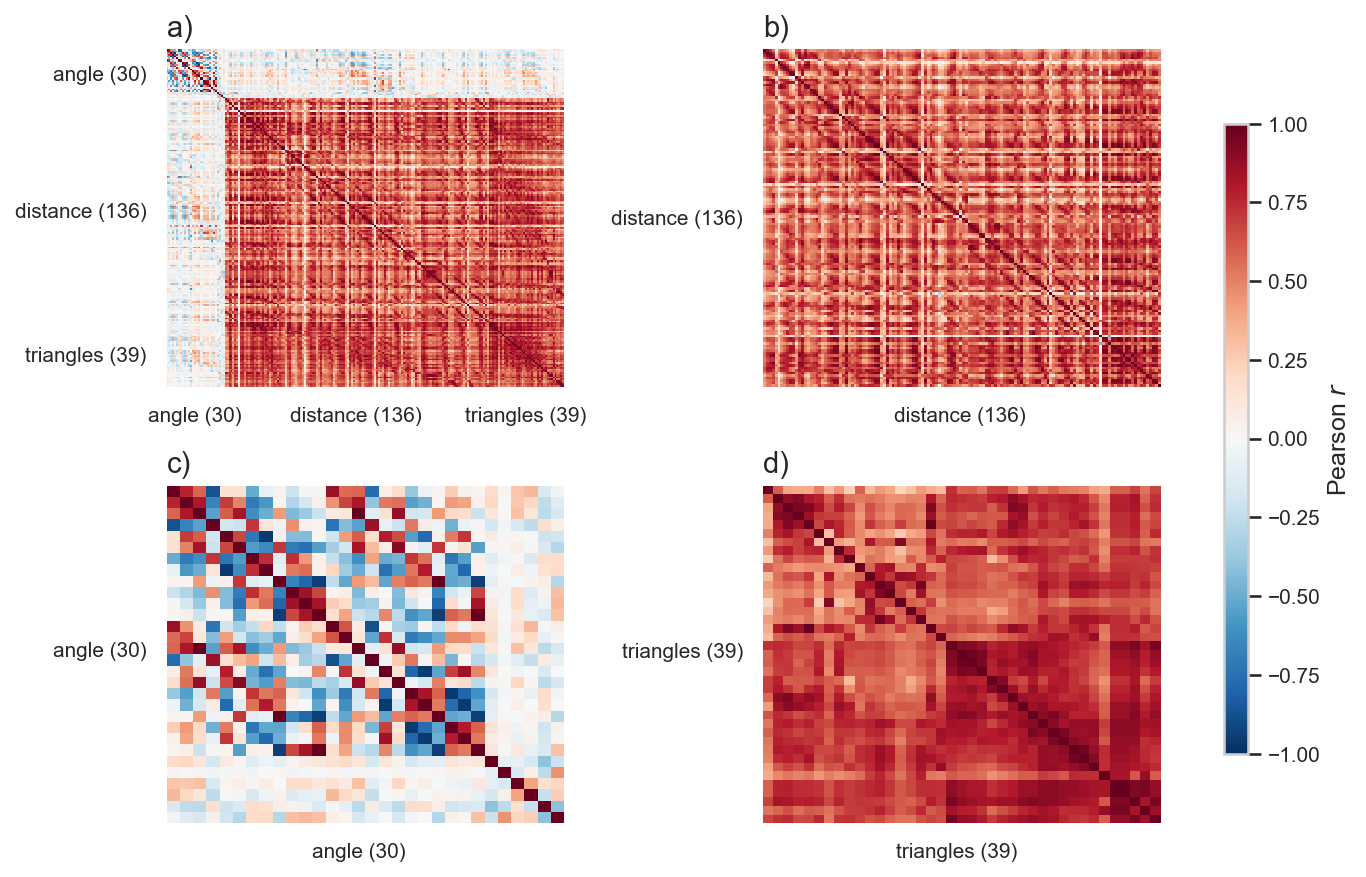

Feature columns: ['dist1_2', 'dist1_3', 'dist1_4', 'dist1_5', 'dist1_6', 'dist1_7', 'dist1_8', 'dist1_9', 'dist1_10', 'dist1_11', 'dist1_12', 'dist1_13', 'dist1_14', 'dist1_15', 'dist1_16', 'dist1_17', 'dist2_3', 'dist2_4', 'dist2_5', 'dist2_6', 'dist2_7', 'dist2_8', 'dist2_9', 'dist2_10', 'dist2_11', 'dist2_12', 'dist2_13', 'dist2_14', 'dist2_15', 'dist2_16', 'dist2_17', 'dist3_4', 'dist3_5', 'dist3_6', 'dist3_7', 'dist3_8', 'dist3_9', 'dist3_10', 'dist3_11', 'dist3_12', 'dist3_13', 'dist3_14', 'dist3_15', 'dist3_16', 'dist3_17', 'dist4_5', 'dist4_6', 'dist4_7', 'dist4_8', 'dist4_9', 'dist4_10', 'dist4_11', 'dist4_12', 'dist4_13', 'dist4_14', 'dist4_15', 'dist4_16', 'dist4_17', 'dist5_6', 'dist5_7', 'dist5_8', 'dist5_9', 'dist5_10', 'dist5_11', 'dist5_12', 'dist5_13', 'dist5_14', 'dist5_15', 'dist5_16', 'dist5_17', 'dist6_7', 'dist6_8', 'dist6_9', 'dist6_10', 'dist6_11', 'dist6_12', 'dist6_13', 'dist6_14', 'dist6_15', 'dist6_16', 'dist6_17', 'dist7_8', 'dist7_9', 'dist7_10', 'dist7_11

In [3]:
# Notebook: High-Level Plot Wrapper Calls with Inline Display and Combined UMAP

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

from FIT_python.config import SPLITS_DIR, RESULTS_DATA_DIR
from FIT_python.Visualisations.plot_style import apply_style, map_sex, SEX_COLORS
from FIT_python.Visualisations.plots_utils import (
    plot_feature_correlation_matrix,
    plot_sex_boxplots,
    plot_umap_scatter
)
from FIT_python.general_pipeline_steps.feature_selection_wrapper import FeatureSelectionTransformer
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# 0) Apply global style & prepare figure directory
apply_style()
fig_dir = Path(RESULTS_DATA_DIR) / "eurasian_otter_fig"
fig_dir.mkdir(exist_ok=True, parents=True)

# 1) Load & preprocess splits
split_dir = Path(SPLITS_DIR) / "eurasian_otter"
train_df = pd.read_parquet(split_dir / "train.parquet")
test_df  = pd.read_parquet(split_dir / "test.parquet")
for df in (train_df, test_df):
    df["sex_mapped"] = map_sex(df["sex"])

# 2) Correlation heatmap panel
display(Markdown("**a) Correlation Heatmap Panel**"))
corr_path = plot_feature_correlation_matrix(train_df, fig_dir)
display(Image(filename=str(corr_path)))

# 3) Select top-4 sex-discriminative features
meta_cols = ["id","species","individual_id","date","location","dataorigin","substrate","sex","trail","Fold"]
feature_cols = [c for c in train_df.columns if c not in meta_cols + ["sex_mapped"]]
print(f"Feature columns: {feature_cols}")   
selector = FeatureSelectionTransformer(method="univariate", k=4)
selector.fit(train_df[feature_cols], train_df["sex_mapped"].map({"Female":0, "Male":1}))
top4 = selector.selected_features_






**b) Boxplots of Top 4 Sex-Discriminative Features**

**a) Train Set**

[CAPTION] Boxplots of features ['dist10_14', 'dist3_10', 'dist9_14', 'dist3_9'] by sex (Female, Male).


**b) Test Set**

[CAPTION] Boxplots of features ['dist10_14', 'dist3_10', 'dist9_14', 'dist3_9'] by sex (Female, Male).


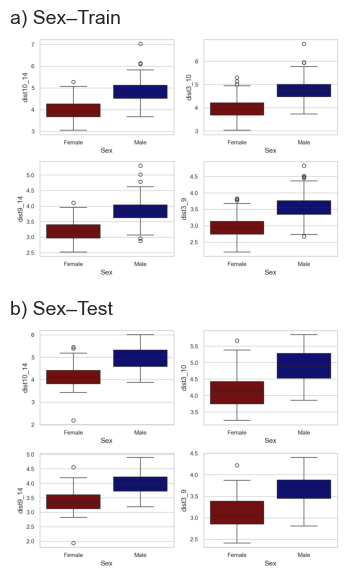

**c) Boxplots of Top 4 Individual-Discriminative Features**

**boxplots_train_individual_top4**

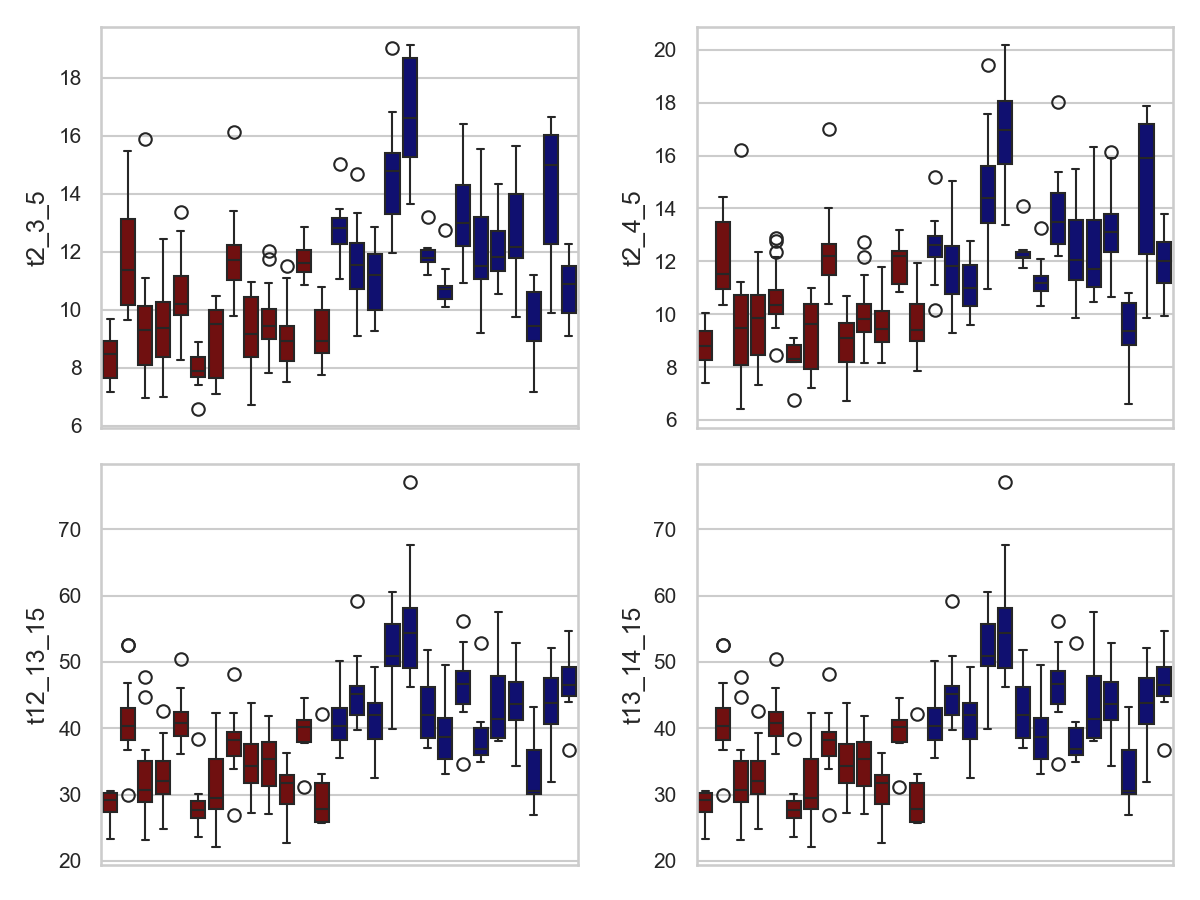

**boxplots_test_individual_top4**

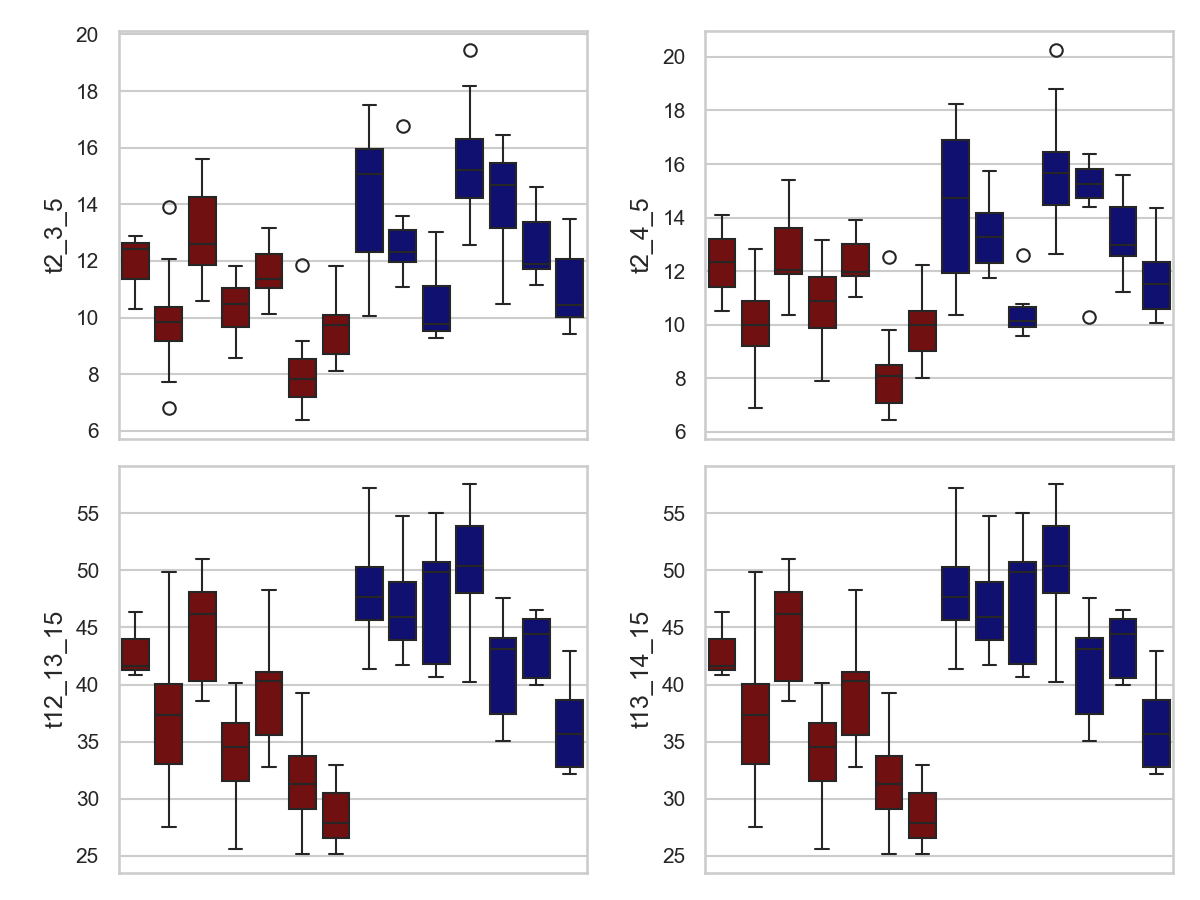

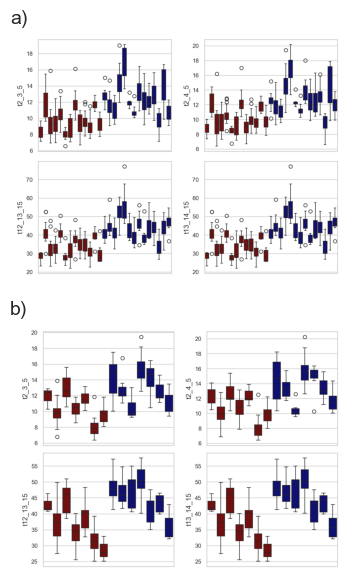

In [4]:
# 3) Select top-4 sex-discriminative features
meta_cols    = ["id","species","individual_id","date","location","dataorigin","substrate","sex","trail","Fold"]
feature_cols = [c for c in train_df.columns if c not in meta_cols + ["sex_mapped"]]

selector = FeatureSelectionTransformer(method="univariate", k=4)
selector.fit(
    train_df[feature_cols],
    train_df["sex_mapped"].map({"Female": 0, "Male": 1})
)
top4 = selector.selected_features_

# 4) Boxplots of Top 4 Sex-Discriminative Features – Train vs. Test
from IPython.display import display, Markdown, Image
import matplotlib.pyplot as plt

display(Markdown("**b) Boxplots of Top 4 Sex-Discriminative Features**"))

# Train block
display(Markdown("**a) Train Set**"))
train_box_path = plot_sex_boxplots(
    train_df, top4, fig_dir,
    filename="boxplots_train_top4.png"
)

# Test block
display(Markdown("**b) Test Set**"))
test_box_path = plot_sex_boxplots(
    test_df, top4, fig_dir,
    filename="boxplots_test_top4.png"
)

# Display the saved Train/Test sex-boxplots vertically
train_img = plt.imread(train_box_path)
test_img  = plt.imread(test_box_path)

fig, axes = plt.subplots(2, 1, figsize=plt.rcParams['figure.figsize'])
axes[0].imshow(train_img); axes[0].axis("off"); axes[0].set_title("a) Sex–Train", loc="left")
axes[1].imshow(test_img);  axes[1].axis("off"); axes[1].set_title("b) Sex–Test",  loc="left")
plt.tight_layout()
plt.show()

# 5) Select top-4 individual-discriminative features
from sklearn.preprocessing import LabelEncoder

le           = LabelEncoder()
train_labels = le.fit_transform(train_df['individual_id'])
selector_ind = FeatureSelectionTransformer(method="univariate", k=4)
selector_ind.fit(train_df[feature_cols], train_labels)
top4_ind     = selector_ind.selected_features_

# --- Helper-Funktion für Individual-Boxplots ---
def plot_individual_boxplots(df, top4_feats, fig_dir, filename):
    """
    Zeichnet 2×2 Boxplots der vier Features in top4_feats,
    geordnet nach sex_mapped (erst alle 'Female', dann 'Male'),
    ohne x-Ticks und ohne Legende, speichert das Bild und gibt den Pfad zurück.
    """
    # Bestimme Reihenfolge der individual_id nach Sex
    female_ids = df.loc[df['sex_mapped']=='Female', 'individual_id'].unique().tolist()
    male_ids   = df.loc[df['sex_mapped']=='Male',   'individual_id'].unique().tolist()
    ind_order  = female_ids + male_ids

    display(Markdown(f"**{filename.replace('.png','')}**"))
    fig, axes = plt.subplots(2, 2, figsize=plt.rcParams['figure.figsize'])
    for ax, feat in zip(axes.flat, top4_feats):
        sns.boxplot(
            data=df,
            x='individual_id', y=feat, ax=ax,
            hue='sex_mapped',
            palette=SEX_COLORS,
            dodge=False,
            order=ind_order,
            hue_order=["Female", "Male"],
            legend=False
        )
        ax.set_xlabel('')
        ax.set_xticks([])
        ax.set_ylabel(feat)
    plt.tight_layout()

    save_path = fig_dir / filename
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    display(Image(filename=str(save_path)))
    return save_path

# 6) Boxplots of Top 4 Individual-Discriminative Features – Train vs. Test
display(Markdown("**c) Boxplots of Top 4 Individual-Discriminative Features**"))

# a) Train Set
train_ind_box_path = plot_individual_boxplots(
    df=train_df,
    top4_feats=top4_ind,
    fig_dir=fig_dir,
    filename="boxplots_train_individual_top4.png"
)

# b) Test Set
test_ind_box_path = plot_individual_boxplots(
    df=test_df,
    top4_feats=top4_ind,
    fig_dir=fig_dir,
    filename="boxplots_test_individual_top4.png"
)

# Finally, display the saved Train/Test individual‑boxplots vertically
train_img = plt.imread(train_ind_box_path)
test_img  = plt.imread(test_ind_box_path)

fig, axes = plt.subplots(2, 1, figsize=plt.rcParams['figure.figsize'])
axes[0].imshow(train_img); axes[0].axis("off"); axes[0].set_title("a)", loc="left")
axes[1].imshow(test_img);  axes[1].axis("off"); axes[1].set_title("b)", loc="left")
plt.tight_layout()
plt.show()


**d) Individual ID Visualisations**

individual_id
otella         32
ottilia        25
rosie          23
rhianna        21
straubing_2    21
Name: count, dtype: int64

**f1) UMAP – full feature set**

C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\1466114751.py:52: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\1466114751.py:52: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('3').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\1466114751.py:52: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\1466114751.py:52: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('2').  Matplotlib is ignoring the edgecolo

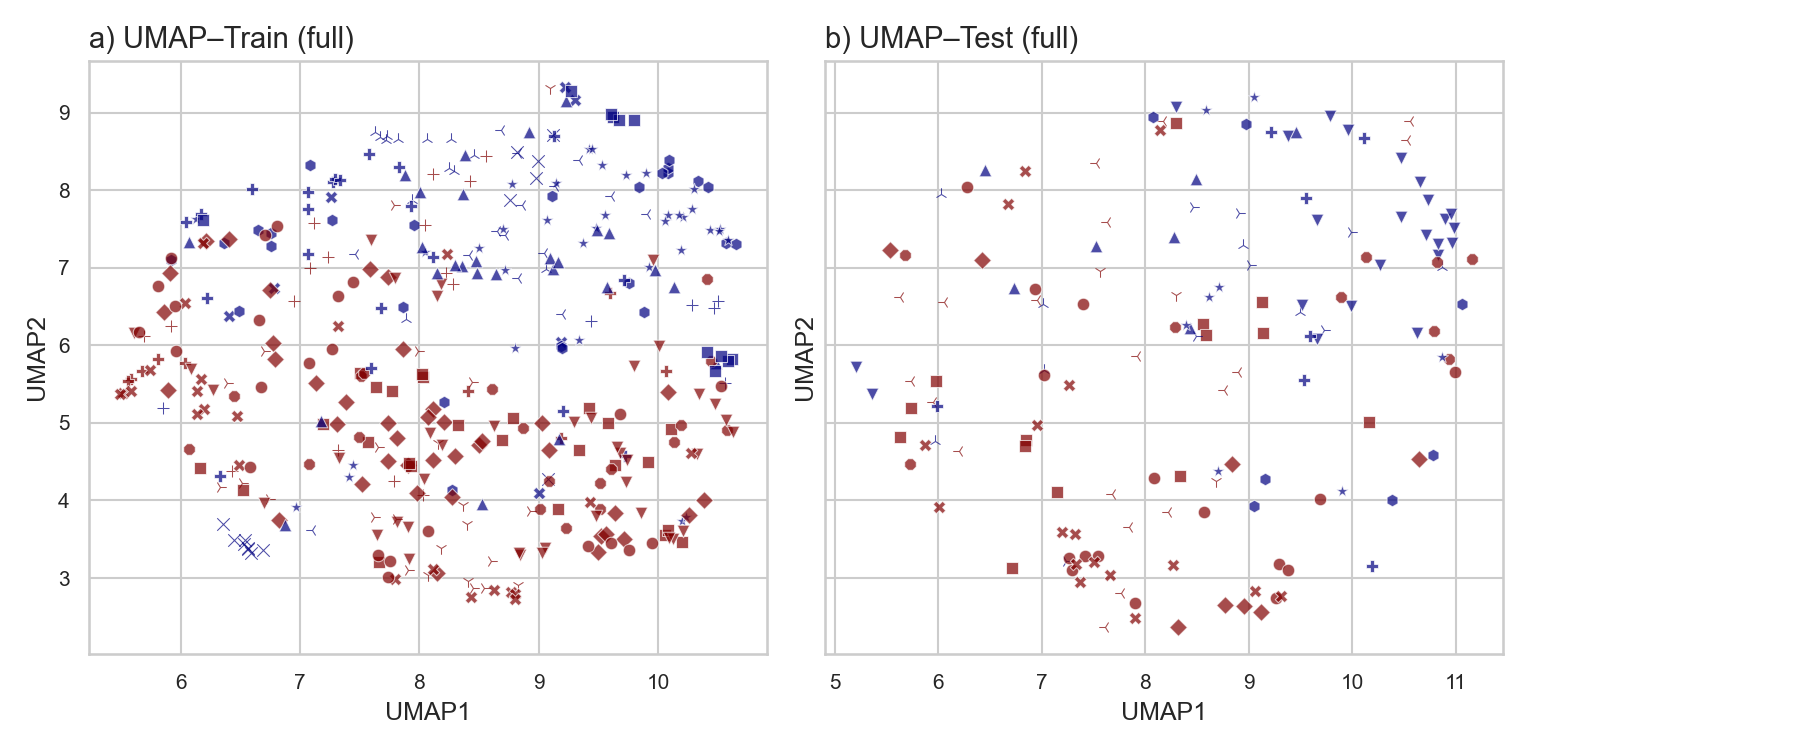

**f2) UMAP – selected 20 RF features**

C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\1466114751.py:100: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\1466114751.py:100: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('3').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\1466114751.py:100: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\1466114751.py:100: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('2').  Matplotlib is ignoring the edge

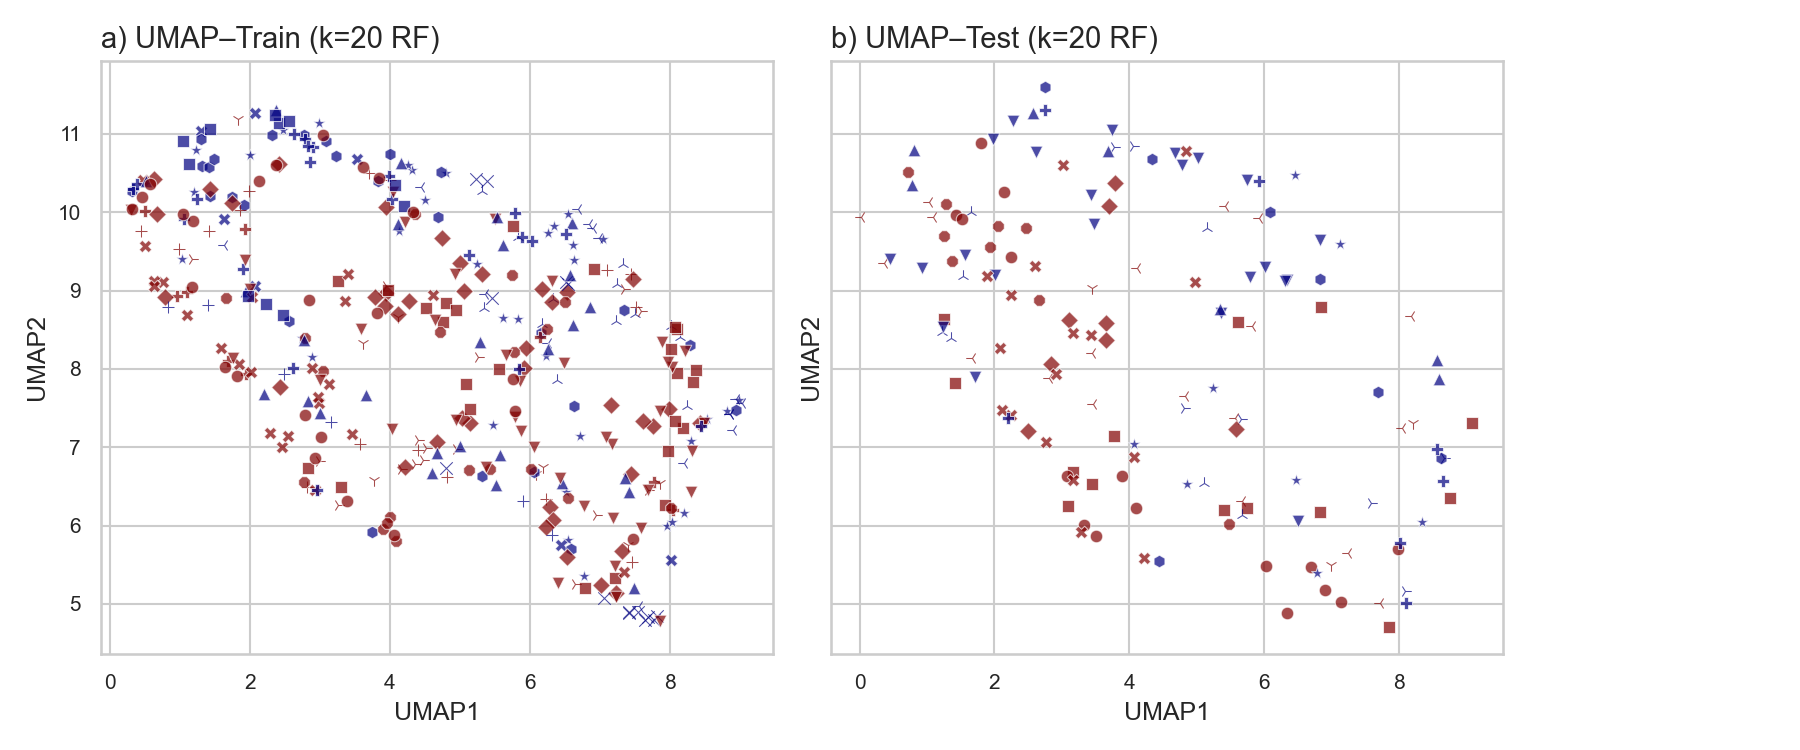

In [5]:
# 6) Visualisations grouped by individual_id (boxplots + dynamic UMAP markers)
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown, Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from itertools import cycle

# d) Individual counts
display(Markdown("**d) Individual ID Visualisations**"))
individual_counts = train_df['individual_id'].value_counts().sort_values(ascending=False)
display(individual_counts.head())

# e) Top‑4 individual‑discriminative features → boxplots (Train vs. Test)
le = LabelEncoder()
train_labels = le.fit_transform(train_df['individual_id'])
selector_ind = FeatureSelectionTransformer(method='univariate', k=4)
selector_ind.fit(train_df[feature_cols], train_labels)
top4_ind = selector_ind.selected_features_

# Build dynamic marker map once
base_markers = ['o','s','^','v','P','X','D','*','h','+','x','1','2','3','4','8']
all_inds     = pd.concat([train_df['individual_id'], test_df['individual_id']]).unique().tolist()
marker_map   = {ind: m for ind, m in zip(all_inds, cycle(base_markers))}
legend_elems = [
    Patch(color=SEX_COLORS['Female'], label='Female'),
    Patch(color=SEX_COLORS['Male'],   label='Male')
]

# f) UMAP Projections by Individual (dynamic markers) – ohne Feature-Selection
display(Markdown("**f1) UMAP – full feature set**"))
# 1) Fit & transform
reducer_full = DimensionalityReducerTransformer(method='umap', n_components=2)
emb_train_full = reducer_full.fit_transform(train_df[feature_cols])
emb_test_full  = reducer_full.transform(test_df[feature_cols])

# 2) Build DataFrames
emb_train_full_df = pd.DataFrame(emb_train_full, columns=['UMAP1','UMAP2'])
emb_train_full_df['individual_id'] = train_df['individual_id']
emb_train_full_df['sex_mapped']    = train_df['sex_mapped']
emb_test_full_df  = pd.DataFrame(emb_test_full, columns=['UMAP1','UMAP2'])
emb_test_full_df['individual_id']  = test_df['individual_id']
emb_test_full_df['sex_mapped']     = test_df['sex_mapped']

# 3) Plot side‑by‑side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, emb_df, title in zip(
        axes,
        (emb_train_full_df, emb_test_full_df),
        ('a) UMAP–Train (full)', 'b) UMAP–Test (full)')
    ):
    for ind, subset in emb_df.groupby('individual_id'):
        ax.scatter(
            subset['UMAP1'], subset['UMAP2'],
            c=SEX_COLORS[subset['sex_mapped'].iloc[0]],
            marker=marker_map[ind],
            label=ind if ax is axes[1] else "",
            alpha=0.7, edgecolor='w', linewidth=0.5
        )
    ax.set_title(title, loc='left')
    ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')

fig.legend(handles=legend_elems, loc='center right', bbox_to_anchor=(1.15,0.5), title='Sex')
fig.tight_layout(rect=[0,0,0.85,1])
umap_full_path = fig_dir / 'umap_ind_full_features.png'
fig.savefig(umap_full_path, dpi=150)
plt.close(fig)
display(Image(filename=str(umap_full_path)))


# f2) UMAP Projections by Individual (dynamic markers) – mit Random-Forest-Feature-Selection (k=20)
display(Markdown("**f2) UMAP – selected 20 RF features**"))

# 0) Random Forest–Selector (k=20)
selector_rf = FeatureSelectionTransformer(method="random_forest", k=20)
selector_rf.fit(train_df[feature_cols], train_df['individual_id'])
train_sel = selector_rf.transform(train_df[feature_cols])
test_sel  = selector_rf.transform(test_df[feature_cols])

# 1) Fit & transform on selektierten Features
reducer_sel = DimensionalityReducerTransformer(method='umap', n_components=2)
emb_train_sel = reducer_sel.fit_transform(train_sel)
emb_test_sel  = reducer_sel.transform(test_sel)

# 2) Build DataFrames
emb_train_sel_df = pd.DataFrame(emb_train_sel, columns=['UMAP1','UMAP2'])
emb_train_sel_df['individual_id'] = train_df['individual_id']
emb_train_sel_df['sex_mapped']    = train_df['sex_mapped']
emb_test_sel_df  = pd.DataFrame(emb_test_sel, columns=['UMAP1','UMAP2'])
emb_test_sel_df['individual_id']  = test_df['individual_id']
emb_test_sel_df['sex_mapped']     = test_df['sex_mapped']

# 3) Plot side‑by‑side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, emb_df, title in zip(
        axes,
        (emb_train_sel_df, emb_test_sel_df),
        ('a) UMAP–Train (k=20 RF)', 'b) UMAP–Test (k=20 RF)')
    ):
    for ind, subset in emb_df.groupby('individual_id'):
        ax.scatter(
            subset['UMAP1'], subset['UMAP2'],
            c=SEX_COLORS[subset['sex_mapped'].iloc[0]],
            marker=marker_map[ind],
            label=ind if ax is axes[1] else "",
            alpha=0.7, edgecolor='w', linewidth=0.5
        )
    ax.set_title(title, loc='left')
    ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')

fig.legend(handles=legend_elems, loc='center right', bbox_to_anchor=(1.15,0.5), title='Sex')
fig.tight_layout(rect=[0,0,0.85,1])
umap_sel_path = fig_dir / 'umap_ind_selected20_rf.png'
fig.savefig(umap_sel_path, dpi=150)
plt.close(fig)
display(Image(filename=str(umap_sel_path)))


**g1) LDA – full feature set**

C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\2688512767.py:40: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\2688512767.py:40: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('3').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\2688512767.py:40: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\2688512767.py:40: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('2').  Matplotlib is ignoring the edgecolo

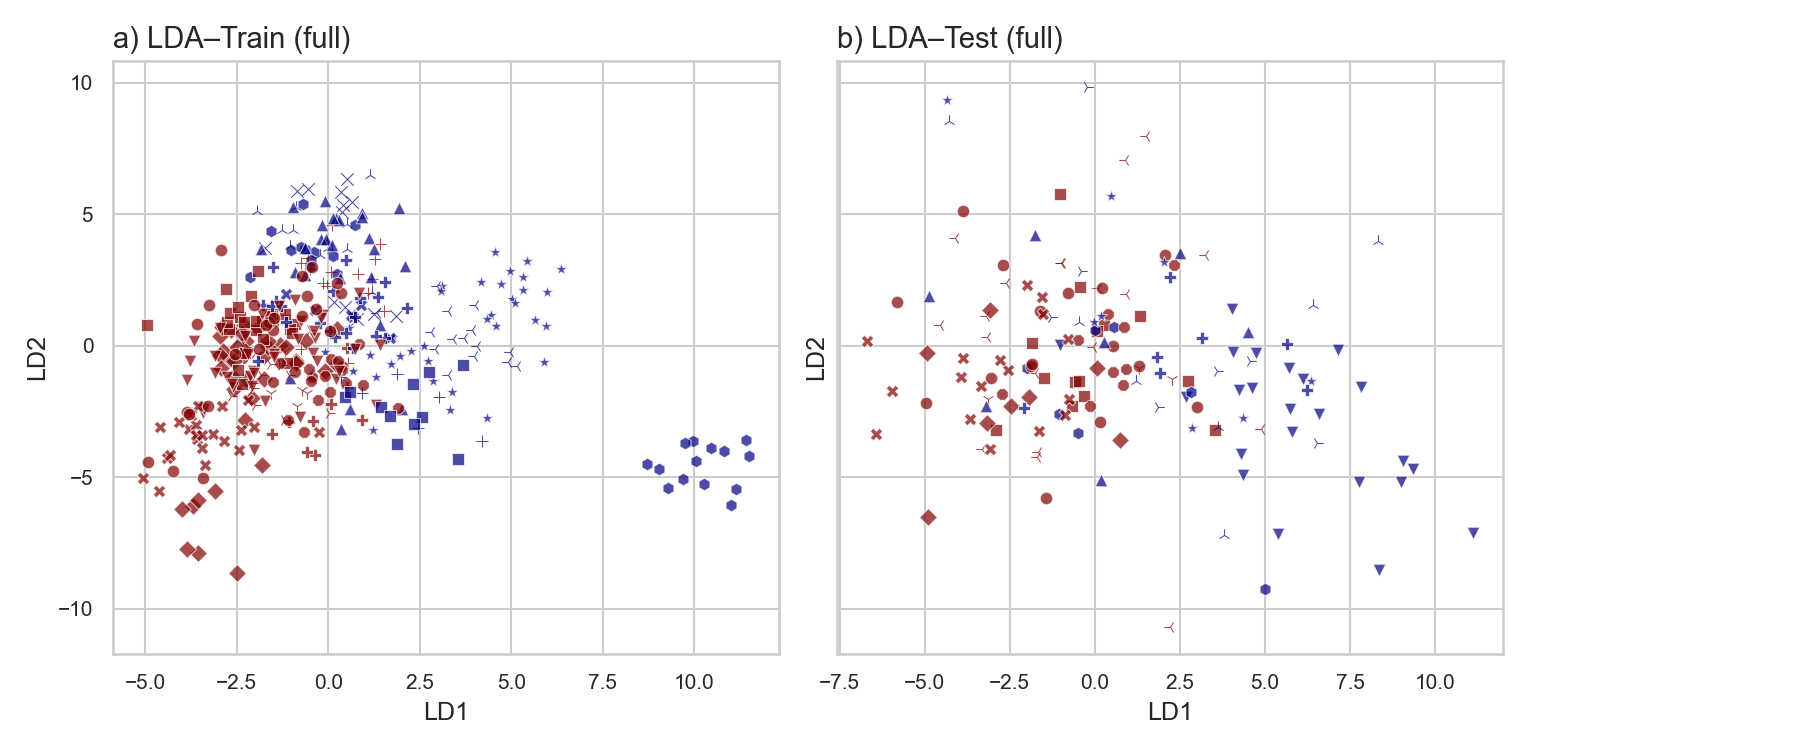

**g2) LDA – selected 20 RF features**

C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\2688512767.py:87: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\2688512767.py:87: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('3').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\2688512767.py:87: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_33788\2688512767.py:87: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('2').  Matplotlib is ignoring the edgecolo

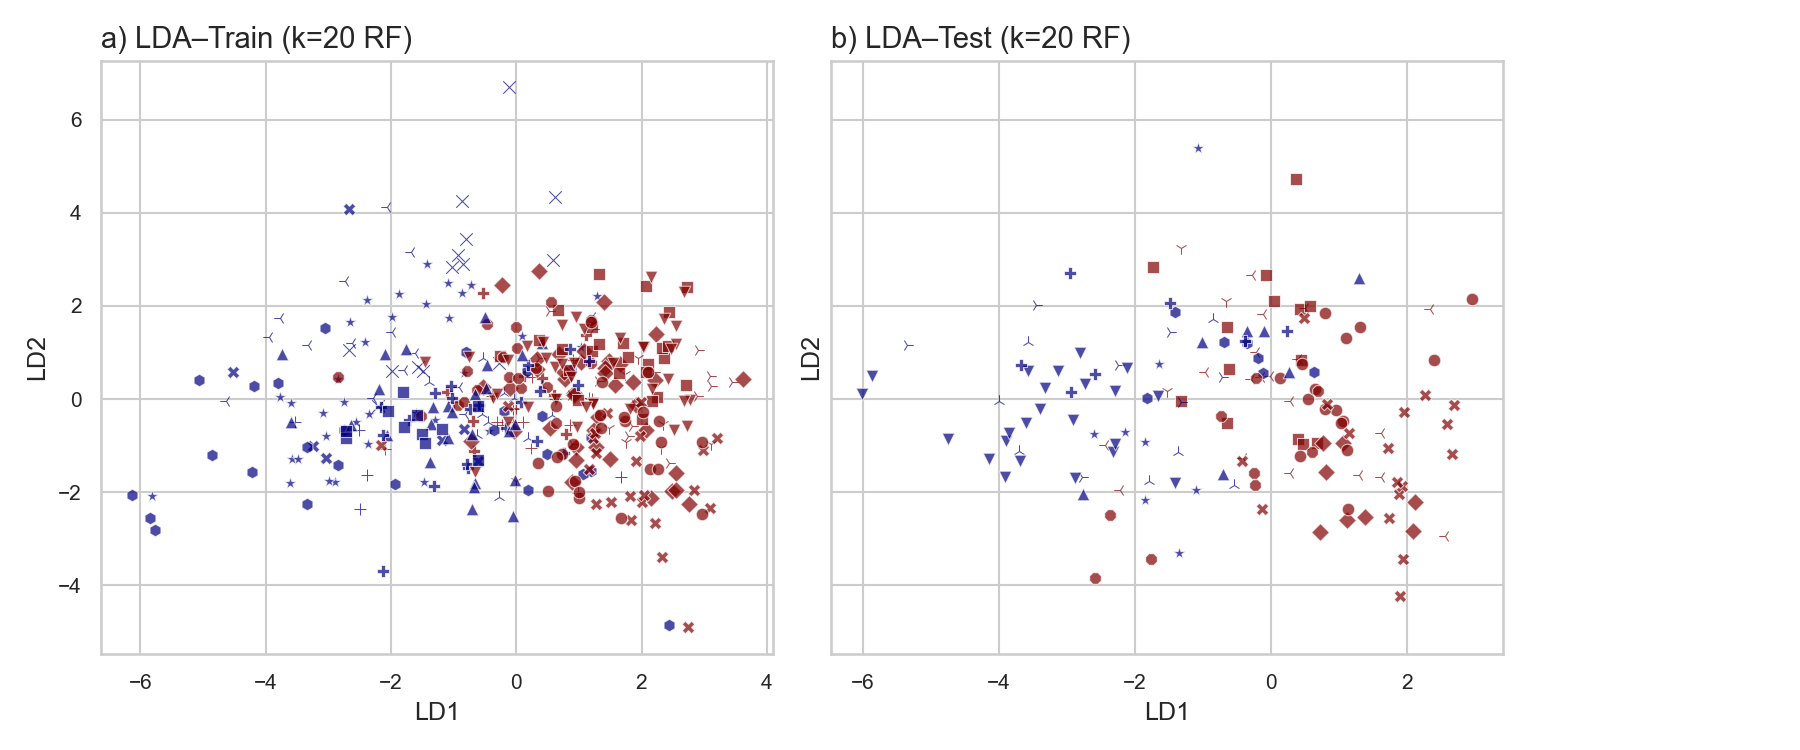

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown, Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from itertools import cycle

# --- Preparations common to both blocks ---
# Build dynamic marker map once
base_markers = ['o','s','^','v','P','X','D','*','h','+','x','1','2','3','4','8']
all_inds     = pd.concat([train_df['individual_id'], test_df['individual_id']]).unique().tolist()
marker_map   = {ind: m for ind, m in zip(all_inds, cycle(base_markers))}

legend_elems = [
    Patch(color=SEX_COLORS['Female'], label='Female'),
    Patch(color=SEX_COLORS['Male'],   label='Male')
]

# g1) LDA Projections by Individual – ohne Feature-Selection
display(Markdown("**g1) LDA – full feature set**"))
lda_full = LDA(n_components=2)
lda_train_full = lda_full.fit_transform(train_df[feature_cols], train_df['individual_id'])
lda_test_full  = lda_full.transform(test_df[feature_cols])

lda_train_full_df = pd.DataFrame(lda_train_full, columns=['LD1','LD2'])
lda_train_full_df['individual_id'] = train_df['individual_id']
lda_train_full_df['sex_mapped']    = train_df['sex_mapped']

lda_test_full_df = pd.DataFrame(lda_test_full, columns=['LD1','LD2'])
lda_test_full_df['individual_id'] = test_df['individual_id']
lda_test_full_df['sex_mapped']    = test_df['sex_mapped']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, df_emb, title in zip(
        axes,
        (lda_train_full_df, lda_test_full_df),
        ('a) LDA–Train (full)', 'b) LDA–Test (full)')
    ):
    for ind, subset in df_emb.groupby('individual_id'):
        ax.scatter(
            subset['LD1'], subset['LD2'],
            c=SEX_COLORS[subset['sex_mapped'].iloc[0]],
            marker=marker_map[ind],
            label=ind if ax is axes[1] else "",
            alpha=0.7, edgecolor='w', linewidth=0.5
        )
    ax.set_title(title, loc='left')
    ax.set_xlabel('LD1'); ax.set_ylabel('LD2')

fig.legend(handles=legend_elems, loc='center right', bbox_to_anchor=(1.15,0.5), title='Sex')
fig.tight_layout(rect=[0,0,0.85,1])

lda_full_path = fig_dir / 'lda_ind_full_features.png'
fig.savefig(lda_full_path, dpi=150)
plt.close(fig)
display(Image(filename=str(lda_full_path)))


# g2) LDA Projections by Individual – mit Random-Forest-Feature-Selection (k=20)
display(Markdown("**g2) LDA – selected 20 RF features**"))
# 0) Random Forest–Selector (k=20)
selector_rf = FeatureSelectionTransformer(method="random_forest", k=20)
selector_rf.fit(train_df[feature_cols], train_df['individual_id'])
train_sel = selector_rf.transform(train_df[feature_cols])
test_sel  = selector_rf.transform(test_df[feature_cols])

# 1) Fit & transform auf selektierten Features
lda_sel = LDA(n_components=2)
lda_train_sel = lda_sel.fit_transform(train_sel, train_df['individual_id'])
lda_test_sel  = lda_sel.transform(test_sel)

lda_train_sel_df = pd.DataFrame(lda_train_sel, columns=['LD1','LD2'])
lda_train_sel_df['individual_id'] = train_df['individual_id']
lda_train_sel_df['sex_mapped']    = train_df['sex_mapped']

lda_test_sel_df = pd.DataFrame(lda_test_sel, columns=['LD1','LD2'])
lda_test_sel_df['individual_id'] = test_df['individual_id']
lda_test_sel_df['sex_mapped']    = test_df['sex_mapped']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, df_emb, title in zip(
        axes,
        (lda_train_sel_df, lda_test_sel_df),
        ('a) LDA–Train (k=20 RF)', 'b) LDA–Test (k=20 RF)')
    ):
    for ind, subset in df_emb.groupby('individual_id'):
        ax.scatter(
            subset['LD1'], subset['LD2'],
            c=SEX_COLORS[subset['sex_mapped'].iloc[0]],
            marker=marker_map[ind],
            label=ind if ax is axes[1] else "",
            alpha=0.7, edgecolor='w', linewidth=0.5
        )
    ax.set_title(title, loc='left')
    ax.set_xlabel('LD1'); ax.set_ylabel('LD2')

fig.legend(handles=legend_elems, loc='center right', bbox_to_anchor=(1.15,0.5), title='Sex')
fig.tight_layout(rect=[0,0,0.85,1])

lda_sel_path = fig_dir / 'lda_ind_selected20_rf.png'
fig.savefig(lda_sel_path, dpi=150)
plt.close(fig)
display(Image(filename=str(lda_sel_path)))


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import multivariate_normal
from IPython.display import display, Markdown, Image
import matplotlib.pyplot as plt
# Ersetze den Import je nach deinem Projekt-Setup:
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper  import DimensionalityReducerTransformer
# --- 0) UMAP auf vollem Feature‑Satz fit & transform für Train & Test ---
reducer   = DimensionalityReducerTransformer(method='umap', n_components=2)
emb_train = reducer.fit_transform(train_df[feature_cols])
emb_test  = reducer.transform(test_df[feature_cols])

train_emb_df = pd.DataFrame(emb_train, columns=['UMAP1','UMAP2'])
train_emb_df[['individual_id','sex_mapped']] = train_df[['individual_id','sex_mapped']]

test_emb_df = pd.DataFrame(emb_test, columns=['UMAP1','UMAP2'])
test_emb_df[['individual_id','sex_mapped']] = test_df[['individual_id','sex_mapped']]



# Markiere Outlier bei 5%-Schwelle (anpassbar via percentile)
train_emb_df = mark_outliers_centroid(train_emb_df, bandwidth=0.5, percentile=10)
test_emb_df  = mark_outliers_centroid(test_emb_df,  bandwidth=0.5, percentile=10)



# Plot für Train
fig_train = plot_umap_centroid_outliers(
    train_emb_df,
    "UMAP–Train: Centroid‑Outlier (5 %-Schwelle)"
)
train_path = fig_dir / 'umap_train_centroid_outliers.png'
fig_train.savefig(train_path, dpi=150)
plt.close(fig_train)
display(Image(filename=str(train_path)))

# Plot für Test
fig_test = plot_umap_centroid_outliers(
    test_emb_df,
    "UMAP–Test: Centroid‑Outlier (5 %-Schwelle)"
)
test_path = fig_dir / 'umap_test_centroid_outliers.png'
fig_test.savefig(test_path, dpi=150)
plt.close(fig_test)
display(Image(filename=str(test_path)))



NameError: name 'plot_umap_centroid_outliers' is not defined

In [ ]:
from FIT_python.pipeline_sex.sex_config import run_otter_search
feature_cols = [c for c in train_df.columns if c not in meta_cols + ["sex_mapped"]]

run_otter_search(n_iter=5, cv=5)


NameError: name 'feature_cols' is not defined